# Bradley-Terry Models Testing: AFL Data

In this notebook, we will be testing the various Bradley-Terry models in our package using data from the Australian Football League (AFL). The data is sourced from [a repository by Kareen (2025)](https://github.com/akareen/AFL-Data-Analysis). Testing is also done here for the various utility functions for conveniently formatting the AFL data for use in our package.

Note: currently, this notebook is used mostly to check things are working properly. It'll be polished up as a proper demo later on. Hi Alan!

In [1]:
# This block is needed to treat our code like a package (for now)
# When it's set up properly later, this will be unnecessary

import os
import sys

root_dir = os.path.dirname(os.path.abspath(os.curdir))
src_dir = os.path.join(root_dir, 'src', 'python')
sys.path.append(src_dir)
# print(sys.path[-1])

In [2]:
import numpy as np
from numpy import ndarray, exp, log
import pandas as pd
from pandas import DataFrame

# Our models and things
from StaticModel import *
from DynamicModel import *
from utils import *

# To format the AFL data for use in our models
from data_utils_afl import *

## Loading Data

For the sake of demonstration, we will use the data from the 2015-2017 seasons, so that there are 3 years of data for the discrete dyanmic models to explore. The data is already separated into different CSVs by year.

Note: data is missing for one match in this timeframe, in the elimination round between Port Adelaide and West Coast. Some further digging reveals that this is probably an issue with the scraper, as this match was a tie (with West Coast winning by 2 in OT). This was manually corrected in the data file.

### Some quick EDA

The following code checks the unique teams and venue names across the 2015-17 seasons, to ensure everything is as expected.

No team changes happened (in the data) during this period. The venues were mostly the same; in 2017, the Bulldogs began playing at Eureka Stadium (Ballarat) and Port Adelaide played at Jiangwan Stadium (Shanghai).

In [3]:
path = "../data/akareen-matches/"
unique_teams = get_unique_teams(path, 2015, 2017)
print(f"Unique teams: {len(unique_teams)}")
print(sorted(list(unique_teams)))

Unique teams: 18
['Adelaide', 'Brisbane Lions', 'Carlton', 'Collingwood', 'Essendon', 'Fremantle', 'Geelong', 'Gold Coast', 'Greater Western Sydney', 'Hawthorn', 'Melbourne', 'North Melbourne', 'Port Adelaide', 'Richmond', 'St Kilda', 'Sydney', 'West Coast', 'Western Bulldogs']


In [4]:
path = "../data/akareen-matches/"
unique_venues = get_unique_venues(path, 2015, 2017)
print(f"Unique venues: {len(unique_venues)}")
print(sorted(list(unique_venues)))
# print(sorted(list(get_unique_venues(path, 2017, 2017))))

Unique venues: 19
['Adelaide Oval', 'Bellerive Oval', 'Carrara', "Cazaly's Stadium", 'Docklands', 'Eureka Stadium', 'Gabba', 'Jiangwan Stadium', 'Kardinia Park', 'M.C.G.', 'Manuka Oval', 'Marrara Oval', 'S.C.G.', 'Stadium Australia', 'Subiaco', 'Sydney Showground', 'Traeger Park', 'Wellington', 'York Park']


### Load the data

Everything is in order, so load the 2015-17 data into the desired (long) format. We see 620 total matches played during this period. Note that we are currently NOT considering neutral venues (but will soon).

In [5]:
path = "../data/akareen-matches/"
df = load_data_afl(path, start_year=2015, end_year=2017)
df

,home,away,home_score,away_score,is_neutral,year
0,Carlton,Richmond,78.0,105.0,0,2015
1,Melbourne,Gold Coast,115.0,89.0,0,2015
2,Sydney,Essendon,72.0,60.0,0,2015
3,Brisbane Lions,Collingwood,74.0,86.0,0,2015
4,Western Bulldogs,West Coast,97.0,87.0,0,2015
...,...,...,...,...,...,...
615,Geelong,Sydney,98.0,39.0,0,2017
616,Greater Western Sydney,West Coast,125.0,58.0,0,2017
617,Adelaide,Geelong,136.0,75.0,0,2017
618,Richmond,Greater Western Sydney,103.0,67.0,0,2017


## Testing Dynamic Models on AFL data

### DyVANBT - Dynamic 'Vanilla' BT model

First we'll look at the dynamic VANBT model. This model requires the win matrices at each time block (i.e., each year/season). Snippets for each year are printed below to check the matrices get created correctly.

In [6]:
dyvan_df = df.drop("is_neutral", axis=1)
dyvan_mat = make_time_blocked_win_matrix(dyvan_df)

for year, mat in dyvan_mat.items():
    print(year)
    print(mat.iloc[:5, :5])
    print()

2015
                Adelaide  Brisbane Lions  Carlton  Collingwood  Essendon
Adelaide             0.0             2.0      1.0          1.0       1.0
Brisbane Lions       0.0             0.0      2.0          0.0       0.0
Carlton              0.0             0.0      0.0          0.0       0.0
Collingwood          0.0             1.0      2.0          0.0       1.0
Essendon             0.0             1.0      1.0          1.0       0.0

2016
                Adelaide  Brisbane Lions  Carlton  Collingwood  Essendon
Adelaide             0.0             1.0      1.0          1.0       1.0
Brisbane Lions       0.0             0.0      1.0          0.0       1.0
Carlton              0.0             1.0      0.0          1.0       1.0
Collingwood          0.0             1.0      1.0          0.0       1.0
Essendon             0.0             0.0      1.0          0.0       0.0

2017
                Adelaide  Brisbane Lions  Carlton  Collingwood  Essendon
Adelaide             0.0          

In [7]:
dyvan_mod = DyVANBT()
dyvan_mod.fit(dyvan_mat, verbose=True)

Optimization terminated successfully.
         Current function value: 325.113010
         Iterations: 24
         Function evaluations: 39
         Gradient evaluations: 39
Successfully fit model parameters.

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 325.1130098944174
        x: [ 2.428e+00  0.000e+00 ...  1.551e+00  1.261e+00]
      nit: 24
      jac: [-1.380e-06 -1.394e-07 ...  5.085e-07 -2.177e-06]
 hess_inv: [[ 9.377e-01  2.447e-02 ... -1.001e-02  4.954e-02]
            [ 2.447e-02  8.690e-01 ...  5.954e-03  3.322e-03]
            ...
            [-1.001e-02  5.954e-03 ...  4.875e-01  8.426e-02]
            [ 4.954e-02  3.322e-03 ...  8.426e-02  8.519e-01]]
     nfev: 39
     njev: 39


DyVANBT()

There is a useful function to look at the ranking across each year. Currently, you can pick the year to sort by (default first year) or by the average strength. This is a slightly simplified version of the summary function, which is still being worked on. The need for dynamism is clear by just looking at how drastically Fremantle changes: from top team to bottom 3!

In [8]:
dyvan_mod.get_ranking()

,Team,2015,2016,2017,Average
0,Fremantle,3.310135,0.572144,0.733181,1.538487
1,West Coast,3.223051,3.505186,1.550594,2.759610
2,Hawthorn,3.187918,3.747169,1.240977,2.725355
3,Sydney,2.786246,3.938576,1.861936,2.862253
4,Richmond,2.595166,1.629189,2.345529,2.189962
5,North Melbourne,2.477351,2.869381,0.177277,1.841336
6,Adelaide,2.427882,3.674128,2.350648,2.817553
7,Western Bulldogs,2.337804,3.878931,1.261043,2.492593
8,Port Adelaide,2.309596,2.121841,1.724783,2.052073
9,Geelong,2.215570,3.984956,2.150656,2.783727


### Compare to individual static BT models

Quick sanity check here. We can see the estimates for the VAN model fitted to just the 2015 data are basically the same as above. Furthermore, the static models have errors implemented right now, so we can see them too. Again, the standard errors will be included naturally in the summary function later (in line with R's `summary` function).

In [11]:
data_2015 = dyvan_mat[2015]
mod_2015 = VANBT()
mod_2015.fit(data_2015)
mod_2015._calculate_errors()
mod_2015.get_ranking()

,Teams,Ability,Error
0,Fremantle,3.310135,0.808074
1,West Coast,3.223051,0.800592
2,Hawthorn,3.187918,0.792995
3,Sydney,2.786247,0.783994
4,Richmond,2.595167,0.786887
5,North Melbourne,2.477352,0.765479
6,Adelaide,2.427883,0.775211
7,Western Bulldogs,2.337805,0.771532
8,Port Adelaide,2.309597,0.781085
9,Geelong,2.215570,0.785328


### DyCHABT - Constant Common Home-ground Advantage BT

Here's my main new contribution to the topic. Let's consider a home-ground advantage (HGA) which remains fixed over time, but still allow the strengths to change. The way we store these win matrices is using a nested dictionary: the outer dict has years, and each inner dict has win matrices for the 3 possible venue types: home, away, and neutral. For our example, we expect 3 venue types over 3 years (although the neutral venue wins are all zero right now). After formatting the data, check the head of the home wins matrix for 2015.

In [ ]:
dycha_mat = make_time_blocked_venue_win_matrices(df)
dycha_mat[2015]["home"].head()

,Adelaide,Brisbane Lions,Carlton,Collingwood,Essendon,Fremantle,Geelong,Gold Coast,Greater Western Sydney,Hawthorn,Melbourne,North Melbourne,Port Adelaide,Richmond,St Kilda,Sydney,West Coast,Western Bulldogs
Adelaide,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0
Brisbane Lions,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
Carlton,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
Collingwood,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
Essendon,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [16]:
dycha_mod = DyCHABT()
dycha_mod.fit(dycha_mat, verbose=True)

Optimization terminated successfully.
         Current function value: 316.697606
         Iterations: 24
         Function evaluations: 43
         Gradient evaluations: 43
Successfully fit model parameters.

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 316.6976059794929
        x: [ 2.545e+00  0.000e+00 ...  1.305e+00  4.010e-01]
      nit: 24
      jac: [-6.290e-07  1.131e-06 ...  2.204e-07  8.078e-06]
 hess_inv: [[ 9.151e-01  5.961e-03 ...  8.534e-04  1.072e-02]
            [ 5.961e-03  8.974e-01 ... -4.288e-03 -5.492e-03]
            ...
            [ 8.534e-04 -4.288e-03 ...  8.070e-01 -1.723e-04]
            [ 1.072e-02 -5.492e-03 ... -1.723e-04  1.170e-02]]
     nfev: 43
     njev: 43


DyCHABT()

In [17]:
dycha_mod.get_ranking()

,Team,2015,2016,2017,Average
0,Fremantle,3.390379,0.566828,0.735666,1.564291
1,Hawthorn,3.335831,3.856589,1.280327,2.824249
2,West Coast,3.255376,3.612968,1.636830,2.835058
3,Sydney,2.860497,3.976342,1.942594,2.926478
4,Richmond,2.645115,1.654755,2.426441,2.242104
5,North Melbourne,2.567833,2.934859,0.218767,1.907153
6,Adelaide,2.544706,3.757823,2.325420,2.875983
7,Western Bulldogs,2.401266,4.050368,1.305405,2.585680
8,Port Adelaide,2.333563,2.191116,1.781106,2.101929
9,Geelong,2.285743,3.976032,2.170489,2.810755


In [22]:
print(f"Constant common HGA: {dycha_mod.get_param('hga'):.5f}")

Constant common HGA: 0.40104


There's still a lot to fix up, but I think this is already quite a cool result (and I'm glad that it seems to be working all correctly!). There does seem to be a fairly non-zero HGA parameter of about 0.40, and the strength estimates seem to be slightly different compared to the `DyVANBT` model before. I still need to add some custom visualisation functions, but maybe we can make a crude attempt now for quick visual comparison. Need to have a think about good ways to visualise this data... lots of variables to consider with the addition of time, how to visualise venue effect, etc.

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

dyvan_rank = dyvan_mod.get_ranking()
dycha_rank = dycha_mod.get_ranking()

In [47]:
dyvan_rank_long = pd.melt(dyvan_rank, id_vars=["Team"], value_vars=dyvan_mod.get_times(), var_name="Year")
dycha_rank_long = pd.melt(dycha_rank, id_vars=["Team"], value_vars=dycha_mod.get_times(), var_name="Year")

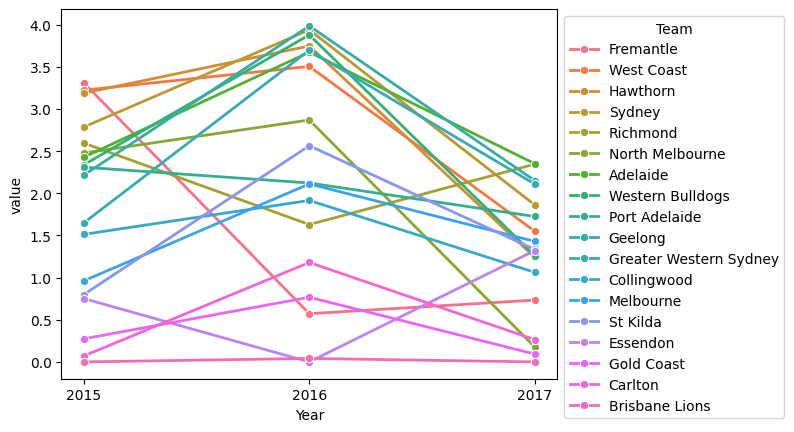

In [46]:
# plt.figure(figsize=(12, 8))
ax = sns.lineplot(data=dyvan_rank_long, x="Year", y="value", hue="Team", marker="o", linewidth=2)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1,1))
plt.xticks(dyvan_mod.get_times())
plt.show()

Plot could be improved but we still gather a lot of interesting things from it. The scale of team strengths is notable, as it seems the 2017 season saw weaker teams (or less dominance, maybe?) compared to previous (we can make such comparisons, right?). Also interesting to see clustering near the top ranks in 2016, so perhaps this was a particularly competitive season. And so on...

Plot below for the DyCHABT results for comparison. Trying to put both rankings on one plot seems infeasible due to the overcrowding (3 * 18 * 2 = 100+ parameter values, plus intervals (or similar) for HGA differences).

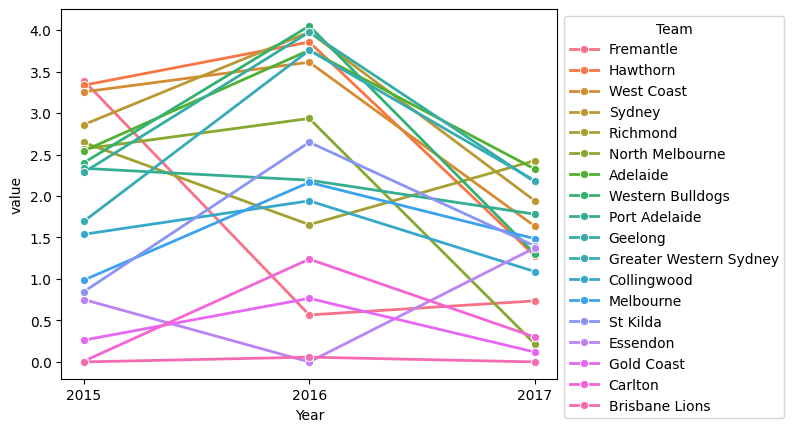

In [48]:
ax = sns.lineplot(data=dycha_rank_long, x="Year", y="value", hue="Team", marker="o", linewidth=2)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1,1))
plt.xticks(dycha_mod.get_times())
plt.show()